# 📊 Sales Data Analysis Dashboard v1.0

## Business Problem

Retail businesses generate thousands of sales transactions every day. Without proper analysis, it is difficult to identify high-performing products, profitable regions, customer purchasing patterns, and operational inefficiencies.

Data-driven decision making helps businesses improve profitability, optimize inventory, and understand customer behavior.

---

## Project Objective

The objective of this project is to analyze historical sales data using Python and identify meaningful business insights through data cleaning, exploratory data analysis (EDA), and visualization.

---

## Project Goals

- Analyze overall sales performance
- Evaluate profit trends
- Identify top-performing products and categories
- Understand customer segments
- Analyze regional performance
- Study the impact of discounts on profitability
- Generate actionable business recommendations

## Importing Required Libraries

Before starting the analysis, we import the required Python libraries.

- **Pandas** → Data manipulation
- **NumPy** → Numerical computations
- **Matplotlib** → Basic visualizations
- **Seaborn** → Advanced statistical visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Better visualization style
plt.style.use("ggplot")

## Loading the Dataset

The dataset is stored in Excel format (.xls). We load it into a Pandas DataFrame for further analysis.

In [5]:
df = pd.read_excel("../data/SampleSuperstore.xls")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Understanding the Dataset

Before cleaning or analyzing the data, it is important to understand its structure, size, columns, and data types.

In [6]:
# Shape of dataset
df.shape

(9994, 21)

In [7]:
# Column names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [8]:
# Basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [9]:
# First five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
# Last five rows
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,2017-05-04,2017-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [11]:
# Missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [12]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

In [13]:
# Statistical summary
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [14]:
# Summary including categorical columns
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,NaN,NaN,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,NaN,NaN,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
min,1.000000,NaN,2014-01-03 00:00:00,2014-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,2015-05-23 00:00:00,2015-05-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,2016-06-26 00:00:00,2016-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,2017-05-14 00:00:00,2017-05-18 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000
max,9994.000000,NaN,2017-12-30 00:00:00,2018-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,99301.000000,NaN,NaN,NaN,NaN,NaN,22638.480000,14.000000,0.800000,8399.976000


### Key Findings

- No missing values were found.
- No duplicate rows were identified.
- Dataset contains 9,994 records and 21 columns.
- Order Date and Ship Date are stored as datetime objects.
- Dataset is ready for further cleaning and exploratory analysis.

## Data Quality Check

The dataset was examined for:

- Missing values
- Duplicate records
- Incorrect data types

Result:
- No missing values found.
- No duplicate records found.
- All data types were appropriate.

Since the dataset was already clean, no additional data cleaning was required.

# Feature Engineering

## Objective

Feature engineering is the process of creating new variables from existing data to make analysis more meaningful.

In this project, we will create date-related features from the **Order Date** column. These features will help us analyze sales trends across years, months, quarters, and weekdays.

In [16]:
# Create new features from Order Date

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = df["Order Date"].dt.month_name()
df["Order Quarter"] = "Q" + df["Order Date"].dt.quarter.astype(str)
df["Order Day"] = df["Order Date"].dt.day
df["Day of Week"] = df["Order Date"].dt.day_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter,Order Day,Day of Week
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,2016,11,November,Q4,8,Tuesday
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,2016,11,November,Q4,8,Tuesday
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,2016,6,June,Q2,12,Sunday
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2015,10,October,Q4,11,Sunday
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,2015,10,October,Q4,11,Sunday


In [17]:
df[[
    "Order Date",
    "Order Year",
    "Order Month",
    "Order Month Name",
    "Order Quarter",
    "Order Day",
    "Day of Week"
]].head()

,Order Date,Order Year,Order Month,Order Month Name,Order Quarter,Order Day,Day of Week
0,2016-11-08,2016,11,November,Q4,8,Tuesday
1,2016-11-08,2016,11,November,Q4,8,Tuesday
2,2016-06-12,2016,6,June,Q2,12,Sunday
3,2015-10-11,2015,10,October,Q4,11,Sunday
4,2015-10-11,2015,10,October,Q4,11,Sunday


## Feature Engineering Summary

The following new features were created:

- **Order Year** – Enables year-wise sales analysis.
- **Order Month** – Useful for chronological sorting.
- **Order Month Name** – Improves readability in charts.
- **Order Quarter** – Supports quarterly performance analysis.
- **Order Day** – Allows day-level analysis if required.
- **Day of Week** – Helps identify sales patterns across weekdays.

These engineered features will be used throughout the exploratory data analysis (EDA) phase.

# Exploratory Data Analysis (EDA)

## Business Question 1

What is the overall business performance?

Before analyzing individual regions, categories, or customers, it is important to understand the company's overall performance through key business metrics.

In [18]:
# Key Performance Indicators (KPIs)

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
average_sales = df["Sales"].mean()
average_profit = df["Profit"].mean()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")
print(f"Average Sales per Transaction: ${average_sales:,.2f}")
print(f"Average Profit per Transaction: ${average_profit:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009
Total Customers: 793
Average Sales per Transaction: $229.86
Average Profit per Transaction: $28.66


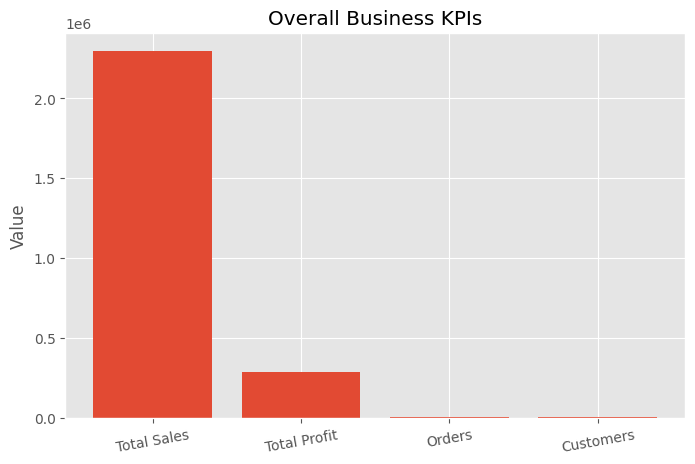

In [19]:
kpis = {
    "Total Sales": total_sales,
    "Total Profit": total_profit,
    "Orders": total_orders,
    "Customers": total_customers
}

plt.figure(figsize=(8,5))
plt.bar(kpis.keys(), kpis.values())
plt.title("Overall Business KPIs")
plt.ylabel("Value")
plt.xticks(rotation=10)
plt.show()

### Business Interpretation

The KPI summary provides a high-level overview of the company's performance.

It highlights the overall sales generated, total profit earned, number of unique orders processed, and the customer base served. These metrics establish a baseline for deeper analysis in the following sections.

### Key Insight

The business has processed a large number of orders across multiple customers, generating substantial sales and profit. Further analysis is required to determine which regions, products, and customer segments contribute the most to this performance.

## Business Question 2

### How have sales changed over time?

Understanding sales trends over time helps businesses identify growth patterns, seasonal demand, and periods of high or low performance.

In [20]:
monthly_sales = (
    df.groupby(["Order Year", "Order Month", "Order Month Name"])["Sales"]
      .sum()
      .reset_index()
)

# Sort months correctly
monthly_sales = monthly_sales.sort_values(
    by=["Order Year", "Order Month"]
)

monthly_sales.head()

,Order Year,Order Month,Order Month Name,Sales
0,2014,1,January,14236.895
1,2014,2,February,4519.892
2,2014,3,March,55691.009
3,2014,4,April,28295.345
4,2014,5,May,23648.287


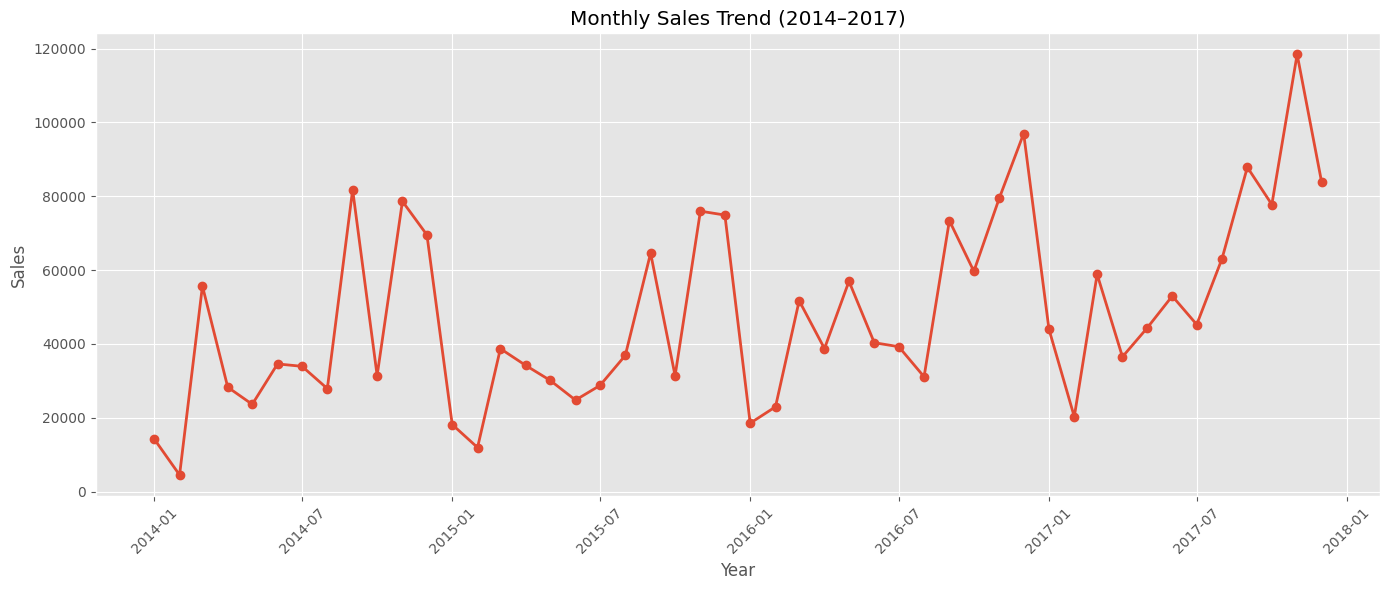

In [22]:
monthly_sales["Year-Month"] = pd.to_datetime(
    monthly_sales["Order Year"].astype(str)
    + "-"
    + monthly_sales["Order Month"].astype(str)
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Year-Month"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend (2014–2017)")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Business Interpretation

The monthly sales trend shows noticeable fluctuations throughout the four-year period (2014–2017). While sales vary from month to month, the overall trend indicates business growth over time, with 2017 recording the strongest monthly sales figures.

Higher sales are observed towards the end of several years, suggesting a possible seasonal increase in customer demand during the final quarter.

### Key Insights

- Sales generally increased over the four-year period, with 2017 being the strongest performing year.
- November 2017 recorded the highest monthly sales during the observed period.
- February 2014 had one of the lowest monthly sales values.
- Several year-end months (especially November and December) consistently show higher sales, indicating a potential seasonal sales pattern.

## Business Question 3

### Which region contributes the most to sales and profit?

Regional analysis helps identify high-performing markets and areas where business performance can be improved.

In [23]:
region_analysis = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

region_analysis

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


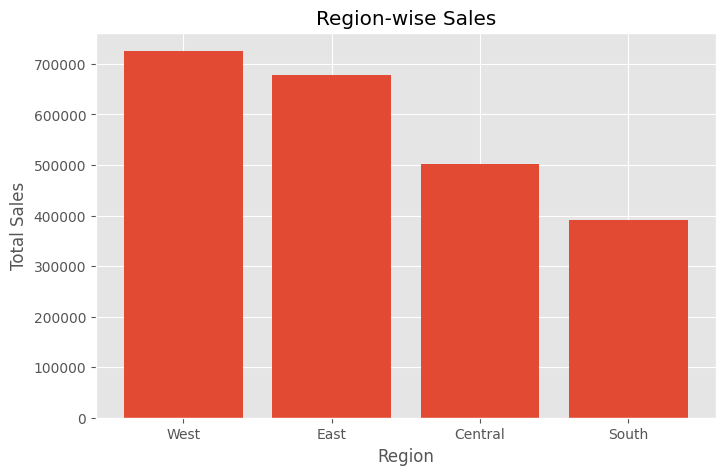

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    region_analysis.index,
    region_analysis["Sales"]
)

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

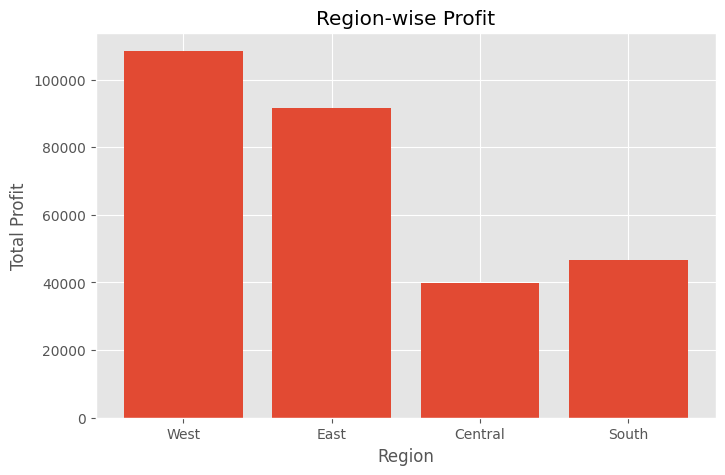

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    region_analysis.index,
    region_analysis["Profit"]
)

plt.title("Region-wise Profit")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.show()

### Observation

- The **West** region recorded the highest total sales.
- The **East** region ranked second in both sales and profit.
- The **Central** region generated higher sales than the South region but reported the lowest overall profit.
- Although the **South** region had the lowest sales, it achieved higher profit than the Central region.

### Business Interpretation

The West region is the strongest-performing market, leading in both sales and profitability, making it a key contributor to the company's overall performance.

The Central region shows comparatively weaker profitability despite generating moderate sales, indicating possible issues such as higher discounts, increased operational costs, or a less profitable product mix.

The South region demonstrates relatively better profitability compared to its sales volume, suggesting efficient business performance in that region.

### Business Recommendations

- Continue investing in the West region to maintain its strong market position.
- Investigate the Central region to identify factors reducing profitability, such as excessive discounts or low-margin products.
- Explore opportunities to increase sales in the South region while maintaining its healthy profit performance.
- Study successful sales strategies used in the West region and replicate them in lower-performing regions where appropriate.

## Business Question 4

### Which product categories and sub-categories contribute the most to sales and profit?

Understanding category and sub-category performance helps businesses identify their best-performing products and areas that require improvement.

In [26]:
category_analysis = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

category_analysis

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


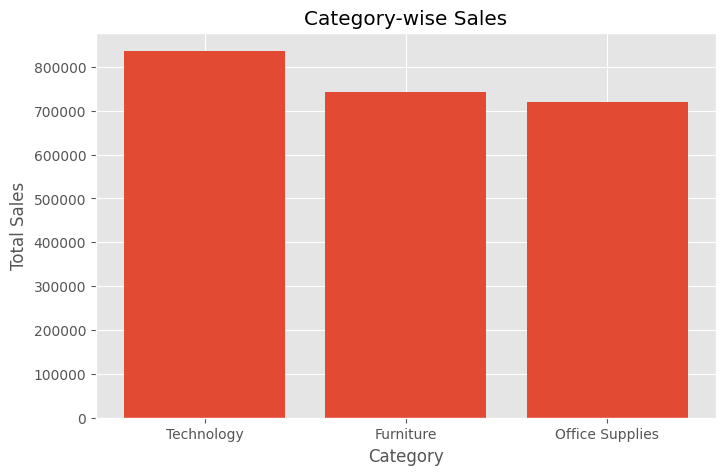

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    category_analysis.index,
    category_analysis["Sales"]
)

plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

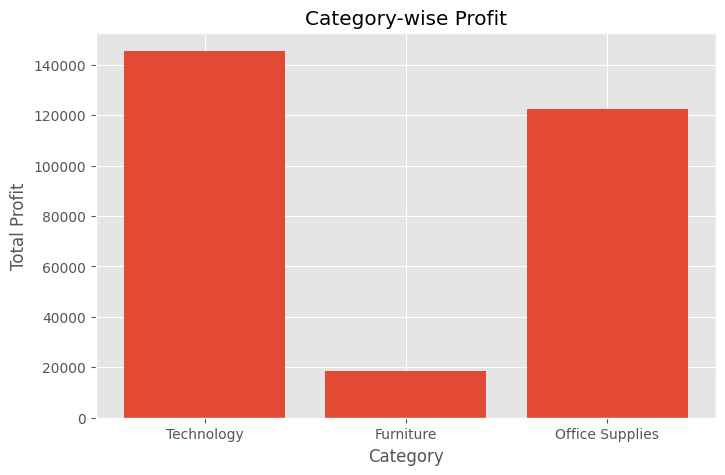

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    category_analysis.index,
    category_analysis["Profit"]
)

plt.title("Category-wise Profit")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

In [29]:
sub_category_analysis = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

sub_category_analysis

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203412.7330,30221.7633
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


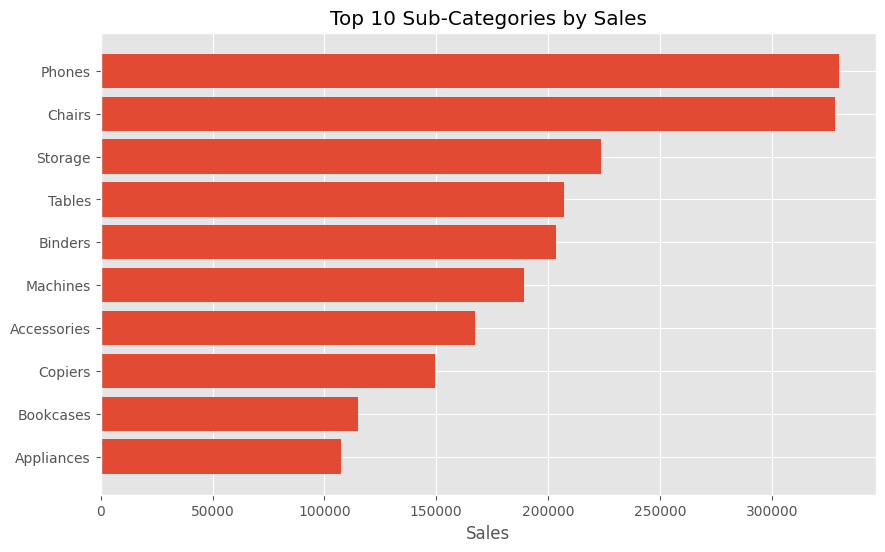

In [30]:
top_sales = sub_category_analysis.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_sales.index,
    top_sales["Sales"]
)

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sales")

plt.gca().invert_yaxis()

plt.show()

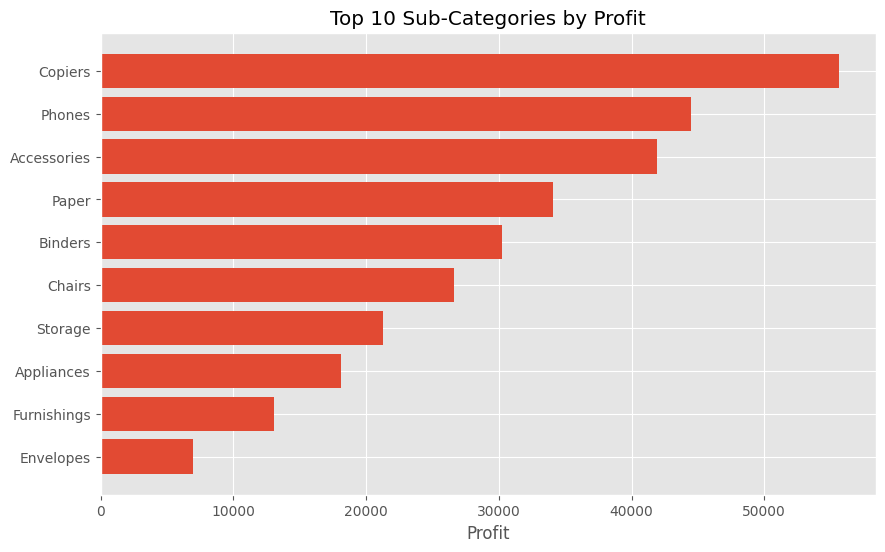

In [31]:
top_profit = (
    sub_category_analysis
    .sort_values(by="Profit", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_profit.index,
    top_profit["Profit"]
)

plt.title("Top 10 Sub-Categories by Profit")
plt.xlabel("Profit")

plt.gca().invert_yaxis()

plt.show()

In [32]:
loss_subcategories = (
    sub_category_analysis
    .sort_values(by="Profit")
)

loss_subcategories.head(10)

,Sales,Profit
Sub-Category,,
Tables,206965.5320,-17725.4811
Bookcases,114879.9963,-3472.5560
Supplies,46673.5380,-1189.0995
Fasteners,3024.2800,949.5182
Machines,189238.6310,3384.7569
Labels,12486.3120,5546.2540
Art,27118.7920,6527.7870
Envelopes,16476.4020,6964.1767
Furnishings,91705.1640,13059.1436


### Observation

- Technology generated the highest total sales among all product categories.
- Furniture ranked second in sales but recorded significantly lower profit compared to the other categories.
- Office Supplies generated slightly lower sales than Furniture but achieved substantially higher profit.
- Phones was the highest-selling sub-category.
- Copiers generated the highest profit among all sub-categories despite not being the highest-selling product.
- Tables recorded the largest financial loss among all sub-categories.
- Bookcases also resulted in a negative profit, although the losses were considerably smaller than Tables.

### Business Interpretation

Technology is the strongest-performing category, contributing significantly to both revenue and profitability. This indicates strong customer demand and healthy profit margins.

Furniture requires closer attention. Although it generates high sales, its profit contribution is disproportionately low, suggesting reduced margins due to factors such as discounts, pricing strategy, or product costs.

The Copiers sub-category demonstrates that high profitability is not always linked to the highest sales volume, highlighting the importance of evaluating profit alongside revenue.

The consistent losses in the Tables and Bookcases sub-categories indicate potential pricing, discounting, or cost-related issues that should be investigated further.

### Business Recommendations

- Continue investing in the Technology category to sustain its strong sales and profitability.
- Investigate the Furniture category to improve profit margins through pricing, supplier negotiations, or discount optimization.
- Promote high-margin products such as Copiers to increase overall profitability.
- Review pricing and discount strategies for Tables and Bookcases, as these products are generating financial losses.
- Focus future marketing campaigns on products that contribute both high sales and strong profits rather than sales volume alone.

### Business Impact

This analysis enables management to identify profitable product categories, prioritize high-performing products, and take corrective actions for loss-making sub-categories. These insights can support pricing decisions, inventory planning, and product portfolio optimization.